In [ ]:
"""corrigir heterocedasticidade."""

import numpy as np
import matplotlib.pyplot as plt
from Filtro_LS import *
from Funcoes_auxiliares import *
from Gerador_de_Sinais import main as gerador_sinal_entrada_saida
from numpy.fft import fft, fftfreq
from numpy.linalg import pinv as inversa
from Funcoes_auxiliares import matriz_observacao

In [118]:
# Consantes & Variáveis #

quantidade_de_amostras = 75

dt = 25 * 10**-9  # tempo entre amostras. Dados proveniente do Shaper
fs = 1 / dt  # frequência de amostragem. 40 MHz
resoluçao = fs / quantidade_de_amostras  # Dados proveniente do Shaper.

In [119]:
sinal_original, Readout_Shaper = gerador_sinal_entrada_saida(
    quantidade_de_amostras, seed=42
)

# Filtro LS 2 

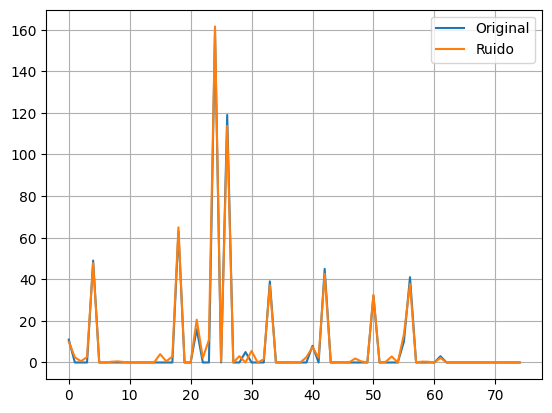

In [120]:
sinal_estimado = filtro_LS_2(
    readout=Readout_Shaper,
    sinal_desejado=sinal_original,
    ordem_filter=7,
    delay=2,
)
plt.plot(sinal_original)
plt.plot(sinal_estimado)
plt.legend(["Original", "Ruido"])
plt.grid()

# Heterocedasticidade

LS assume variância constante do erro.

Espalhamento aumenta com amplitude = Heterocedasticidade:
Var(erro)∝∣sinal|  

A heterocedasticidade ocorre na regressão linear quando a variância dos resíduos (erros) não é constante ao longo dos valores da variável independente.



In [80]:
ruido = sinal_estimado - sinal_original  # dt_ruido = dt_sinal_original
erro = ruido

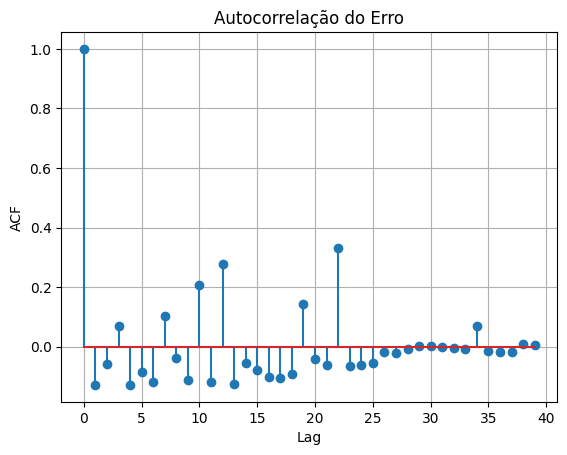

In [91]:
def autocorrelacao(x):
    result = np.correlate(x, x, mode="full")
    return result[result.size // 2 :]


erro = erro - np.mean(erro)

acf = autocorrelacao(erro)
acf = acf / acf[0]  # normalizar

plt.stem(acf[:40])
plt.title("Autocorrelação do Erro")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.grid()
plt.show()

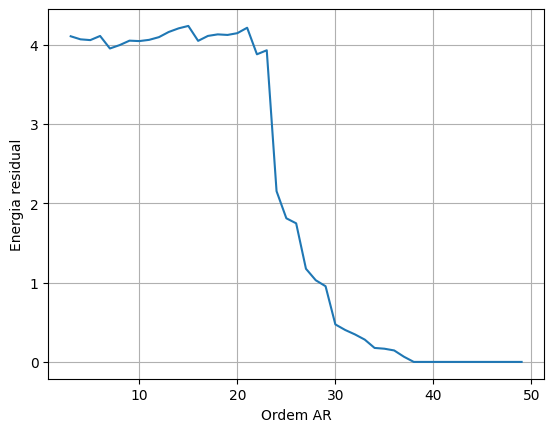

In [ ]:
def ajustar_AR(erro, ordem):
    erro = erro - np.mean(erro)

    N = len(erro)

    Y = erro[ordem:]

    X = np.column_stack([erro[ordem - i - 1 : N - i - 1] for i in range(ordem)])

    coef = np.linalg.pinv(X) @ Y

    return coef


ordens_ar = range(3, 50)
energia_residual = []

for p in ordens_ar:
    coef = ajustar_AR(erro, p)

    N = len(erro)
    Y = erro[p:]
    X = np.column_stack([erro[p - i - 1 : N - i - 1] for i in range(p)])

    erro_residual = Y - X @ coef

    energia = np.mean(erro_residual**2)
    energia_residual.append(energia)

plt.plot(ordens_ar, energia_residual)
plt.xlabel("Ordem AR")
plt.ylabel("Energia residual")
plt.grid()
plt.show()

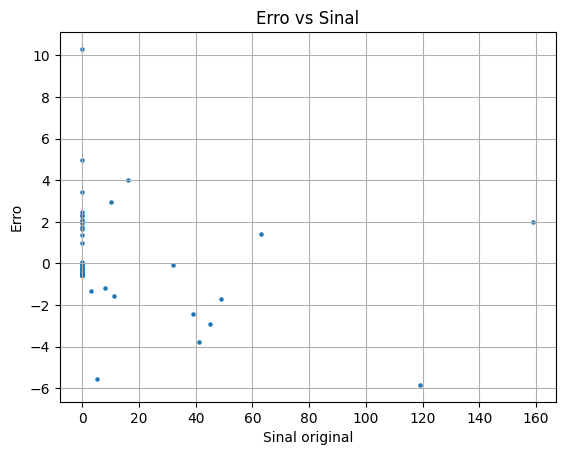

In [ ]:
plt.scatter(sinal_original[: len(erro)], erro, s=5)
plt.xlabel("Sinal original")
plt.ylabel("Erro")
plt.title("Erro vs Sinal")
plt.grid()
plt.show()

In [ ]:
X_nl = np.column_stack(
    [sinal_original[: len(erro)], sinal_original[: len(erro)] ** 2, np.ones(len(erro))]
)

coef_nl = np.linalg.pinv(X_nl) @ erro

erro_novo = erro - X_nl @ coef_nl

print("Energia antes:", np.mean(erro**2))
print("Energia depois:", np.mean(erro_novo**2))

Energia antes: 4.335544776606521
Energia depois: 3.953722741372945


Redução na energia do erro: Existe componente não linear leve.

# Filtro WLS

In [ ]:
# WLS


def filtro_WLS(
    sinal_desejado: list | np.ndarray,
    readout: list | np.ndarray,
    ordem_filter: int = 7,
    delay: int = 2,
    eps: float = 1e-6,
    valor_max_clip: int | None = None,
    valor_min_clip: int = 0,
    normalizar_pesos: bool = True,
):
    readout_shaper = np.clip(readout, valor_min_clip, valor_max_clip)

    X = matriz_observacao(readout_shaper, ordem_filtro=ordem_filter)  # (m, ordem)
    y_full = np.asarray(sinal_desejado)

    # tamanho válido para casar X e y com delay
    n_valid = min(X.shape[0], len(y_full) - delay)
    if n_valid <= 0:
        raise ValueError(
            f"Sem amostras válidas para ordem={ordem_filter}, delay={delay}. "
            f"len(X)={X.shape[0]}, len(y)={len(y_full)}"
        )

    X = X[:n_valid]
    y = y_full[delay : delay + n_valid]

    Xb = np.column_stack([X, np.ones(X.shape[0])])  # bias
    w = 1.0 / (np.abs(y) + eps)

    if normalizar_pesos:
        w = w / np.mean(w)

    sw = np.sqrt(w)
    Xw = Xb * sw[:, None]
    yw = y * sw

    beta = inversa(Xw.T @ Xw) @ Xw.T @ yw

    sinal_estimado = np.zeros(len(readout_shaper), dtype=float)
    sinal_estimado[:n_valid] = Xb @ beta
    sinal_estimado = np.clip(sinal_estimado, valor_min_clip, valor_max_clip)
    return sinal_estimado


#


def calcular_erro_para_ordem(
    sinais_estimados,  # dict: {ordem: sinal_estimado}
    sinal_desejado,
    delay,
):
    sinal_desejado = np.asarray(sinal_desejado)

    erros_por_ordem = {}
    ordem_menor_erro = None
    menor_erro = np.inf

    for ordem, sinal_estimado in sinais_estimados.items():
        sinal_estimado = np.asarray(sinal_estimado)

        end = len(sinal_desejado) - ordem + 1
        estimado_eval = sinal_estimado[:end]
        desejado_eval = sinal_desejado[delay : delay + end]

        if len(estimado_eval) != len(desejado_eval):
            raise ValueError(
                f"Ordem {ordem}: tamanhos diferentes "
                f"(estimado={len(estimado_eval)} vs desejado={len(desejado_eval)})"
            )

        erro = estimado_eval - desejado_eval
        rms_erro = np.sqrt(np.mean(erro**2))
        rms_sinal = np.sqrt(np.mean(desejado_eval**2))
        erro_relativo = rms_erro / (rms_sinal + 1e-12)

        erros_por_ordem[ordem] = erro_relativo

        if erro_relativo < menor_erro:
            menor_erro = erro_relativo
            ordem_menor_erro = ordem

    return erros_por_ordem, ordem_menor_erro, menor_erro


#
def buscar_delay_ideal(
    filtro,
    sinal_desejado,
    readout,
    ordem_filter,
    delay_max=12,
    criterio="rmse",  # "rmse" ou "mae"
    **filtro_kwargs,
):
    sinal_desejado = np.asarray(sinal_desejado)
    delays = list(range(delay_max + 1))
    erros_rmse = []
    erros_mae = []

    for d in delays:
        sinal_estimado = filtro(
            sinal_desejado=sinal_desejado,
            readout=readout,
            ordem_filter=ordem_filter,
            delay=d,
            **filtro_kwargs,
        )

        # alinhamento válido
        end = len(sinal_desejado) - ordem_filter + 1
        estimado_eval = np.asarray(sinal_estimado)[:end]
        desejado_eval = sinal_desejado[d : d + end]

        # proteção de tamanho
        n = min(len(estimado_eval), len(desejado_eval))
        estimado_eval = estimado_eval[:n]
        desejado_eval = desejado_eval[:n]

        rmse, mae = RMSE_e_MAE_por_ordem(estimado_eval, desejado_eval)
        erros_rmse.append(rmse)
        erros_mae.append(mae)

    if criterio.lower() == "mae":
        idx_best = int(np.argmin(erros_mae))
        erro_best = erros_mae[idx_best]
    else:
        idx_best = int(np.argmin(erros_rmse))
        erro_best = erros_rmse[idx_best]

    delay_best = delays[idx_best]
    return delays, erros_rmse, erros_mae, delay_best, erro_best


#


def grid_search_2d_ordem_delay(
    filtro,
    sinal_desejado,
    readout,
    ordens=range(3, 30),
    delays=range(0, 13),
    criterio="rmse",  # "rmse" ou "mae"
    **filtro_kwargs,
):
    sinal_desejado = np.asarray(sinal_desejado)
    resultados = []

    melhor = {
        "ordem": None,
        "delay": None,
        "rmse": np.inf,
        "mae": np.inf,
    }

    for ordem in ordens:
        for delay in delays:
            try:
                sinal_estimado = filtro(
                    sinal_desejado=sinal_desejado,
                    readout=readout,
                    ordem_filter=ordem,
                    delay=delay,
                    **filtro_kwargs,
                )
            except ValueError:
                resultados.append(
                    {
                        "ordem": ordem,
                        "delay": delay,
                        "rmse": "ValueError",
                        "mae": "ValueError",
                    }
                )
                continue

            n_valid = min(len(readout) - ordem + 1, len(sinal_desejado) - delay)
            if n_valid <= 0:
                resultados.append(
                    {
                        "ordem": ordem,
                        "delay": delay,
                        "rmse": "n_invalid",
                        "mae": "n_invalid",
                    }
                )
                continue

            est_eval = np.asarray(sinal_estimado)[:n_valid]
            des_eval = sinal_desejado[delay : delay + n_valid]

            rmse, mae = RMSE_e_MAE_por_ordem(est_eval, des_eval)

            resultados.append(
                {"ordem": ordem, "delay": delay, "rmse": rmse, "mae": mae}
            )

            score_atual = rmse if criterio.lower() == "rmse" else mae
            score_melhor = (
                melhor["rmse"] if criterio.lower() == "rmse" else melhor["mae"]
            )

            if score_atual < score_melhor:
                melhor = {"ordem": ordem, "delay": delay, "rmse": rmse, "mae": mae}

    return melhor, resultados


#

In [ ]:
melhor, resultados = grid_search_2d_ordem_delay(
    filtro=filtro_WLS,
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordens=range(3, 50),
    delays=range(0, 13),
    criterio="rmse",
    eps=1e-6,
    valor_min_clip=0,
    valor_max_clip=None,
    normalizar_pesos=True,
)

print("Melhor combinação:")
print(
    f"ordem={melhor['ordem']}, delay={melhor['delay']}, RMSE={melhor['rmse']:.6f}, MAE={melhor['mae']:.6f}"
)

Melhor combinação:
ordem=46, delay=9, RMSE=0.000000, MAE=0.000000


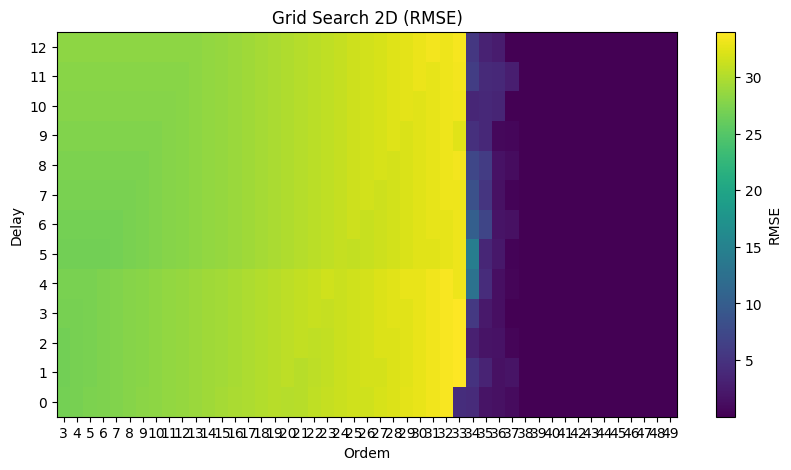

In [ ]:
import pandas as pd

df = pd.DataFrame(resultados)
pivot = df.pivot(index="delay", columns="ordem", values="rmse")  # ou "mae"

plt.figure(figsize=(10, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower", interpolation="nearest")
plt.colorbar(label="RMSE")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Ordem")
plt.ylabel("Delay")
plt.title("Grid Search 2D (RMSE)")
plt.show()

In [ ]:
ordens = range(3, 30)
max(ordens)

29

In [130]:
# Confirmação rápida de overfitting: erro treino x validação por ordem
# (mantém delay fixo ou use o delay da sua busca)

import numpy as np
import matplotlib.pyplot as plt


def confirmar_overfitting_rapido(
    filtro,
    sinal_desejado,
    readout,
    ordem_maxima=30,
    delay=2,
    frac_treino=0.7,
    **filtro_kwargs,
):
    y = np.asarray(sinal_desejado)
    x = np.asarray(readout)

    n = min(len(x), len(y))
    n_train = int(n * frac_treino)

    x_train, y_train = x[:n_train], y[:n_train]
    x_val, y_val = x[n_train:], y[n_train:]

    rmse_train, rmse_val = [], []
    mae_train, mae_val = [], []

    ordens_validas = []

    for ordem in range(3, ordem_maxima + 1):
        # precisa de amostras suficientes em ambos os blocos
        if (len(x_train) - ordem + 1) <= 0 or (len(y_train) - delay) <= 0:
            continue
        if (len(x_val) - ordem + 1) <= 0 or (len(y_val) - delay) <= 0:
            continue

        # Treina no treino
        est_train = filtro(
            sinal_desejado=y_train,
            readout=x_train,
            ordem_filter=ordem,
            delay=delay,
            **filtro_kwargs,
        )

        n_eval_train = min(len(x_train) - ordem + 1, len(y_train) - delay)
        ytr = y_train[delay : delay + n_eval_train]
        etr = np.asarray(est_train)[:n_eval_train]
        r_tr, m_tr = RMSE_e_MAE_por_ordem(etr, ytr)

        # Treina separadamente no bloco de validação só para avaliar tendência
        # (rápido e simples; ideal mesmo seria treinar no treino e aplicar no val com pesos congelados)
        est_val = filtro(
            sinal_desejado=y_val,
            readout=x_val,
            ordem_filter=ordem,
            delay=delay,
            **filtro_kwargs,
        )

        n_eval_val = min(len(x_val) - ordem + 1, len(y_val) - delay)
        yv = y_val[delay : delay + n_eval_val]
        ev = np.asarray(est_val)[:n_eval_val]
        r_va, m_va = RMSE_e_MAE_por_ordem(ev, yv)

        ordens_validas.append(ordem)
        rmse_train.append(r_tr)
        rmse_val.append(r_va)
        mae_train.append(m_tr)
        mae_val.append(m_va)

    # melhores ordens
    i_tr = int(np.argmin(rmse_train))
    i_va = int(np.argmin(rmse_val))

    print(
        f"Melhor ordem (RMSE treino): {ordens_validas[i_tr]} | RMSE={rmse_train[i_tr]:.6f}"
    )
    print(
        f"Melhor ordem (RMSE valid):  {ordens_validas[i_va]} | RMSE={rmse_val[i_va]:.6f}"
    )

    # regra 1%: menor ordem dentro de 1% do melhor de validação
    melhor_val = np.min(rmse_val)
    lim = melhor_val * 1.01
    candidatas = [o for o, e in zip(ordens_validas, rmse_val) if e <= lim]
    ordem_parcimoniosa = min(candidatas) if candidatas else ordens_validas[i_va]
    print(f"Ordem parcimoniosa (<=1% do melhor val): {ordem_parcimoniosa}")

    plt.figure(figsize=(9, 4))
    plt.plot(ordens_validas, rmse_train, marker="o", label="RMSE treino")
    plt.plot(ordens_validas, rmse_val, marker="s", label="RMSE validação")
    plt.axvline(
        ordens_validas[i_va],
        color="red",
        linestyle="--",
        label=f"Melhor val = {ordens_validas[i_va]}",
    )
    plt.xlabel("Ordem")
    plt.ylabel("RMSE")
    plt.title("Treino vs Validação por Ordem")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return {
        "ordens": ordens_validas,
        "rmse_treino": rmse_train,
        "rmse_valid": rmse_val,
        "mae_treino": mae_train,
        "mae_valid": mae_val,
        "melhor_ordem_treino": ordens_validas[i_tr],
        "melhor_ordem_valid": ordens_validas[i_va],
        "ordem_parcimoniosa_1pct": ordem_parcimoniosa,
    }

Melhor ordem (RMSE treino): 3 | RMSE=31.851844
Melhor ordem (RMSE valid):  23 | RMSE=0.000000
Ordem parcimoniosa (<=1% do melhor val): 23


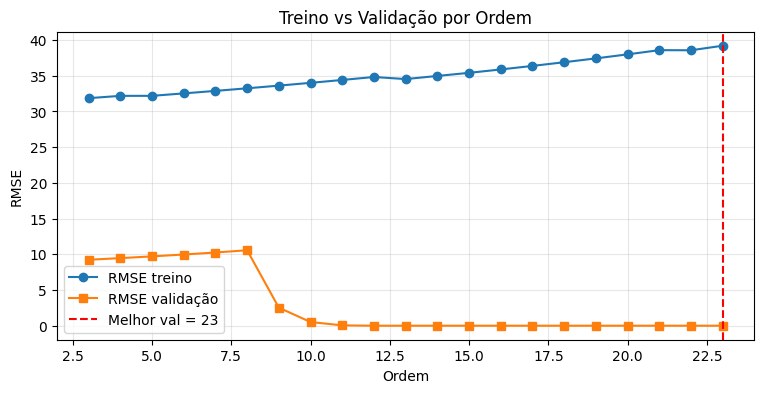

In [ ]:
res = confirmar_overfitting_rapido(
    filtro=filtro_WLS,
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    # ordens=range(3, 30),
    delay=2,  # ou delay_best
    frac_treino=0.7,
    eps=1e-6,
    valor_min_clip=0,
    valor_max_clip=None,
    normalizar_pesos=True,
)

In [109]:
ordens = range(3, 30)


sinais_estimados = {}
for ordem in ordens:
    sinais_estimados[ordem] = filtro_WLS(
        sinal_desejado=sinal_original,
        readout=Readout_Shaper,
        ordem_filter=ordem,
        delay=0,
    )

erros_por_ordem, ordem_menor_erro, menor_erro = calcular_erro_para_ordem(
    sinais_estimados=sinais_estimados,
    sinal_desejado=sinal_original,
    delay=0,
)

print(f"ordem_menor_erro = {ordem_menor_erro}")
print(f"menor_erro = {menor_erro:.6f}")

ordem_menor_erro = 29
menor_erro = 0.000000


In [111]:
ordem_fixada = ordem_menor_erro  # ou um valor fixo, ex: 7

delays, erros_rmse, erros_mae, delay_best, erro_best = buscar_delay_ideal(
    filtro=filtro_WLS,
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_fixada,
    delay_max=12,
    criterio="rmse",
    eps=1e-6,
    valor_min_clip=0,
    valor_max_clip=None,
    normalizar_pesos=True,
)

print(f"Melhor delay = {delay_best}")
print(f"Erro ({'RMSE'}) no melhor delay = {erro_best:.6f}")

#

Melhor delay = 8
Erro (RMSE) no melhor delay = 0.000000


Melhor ordem = 29


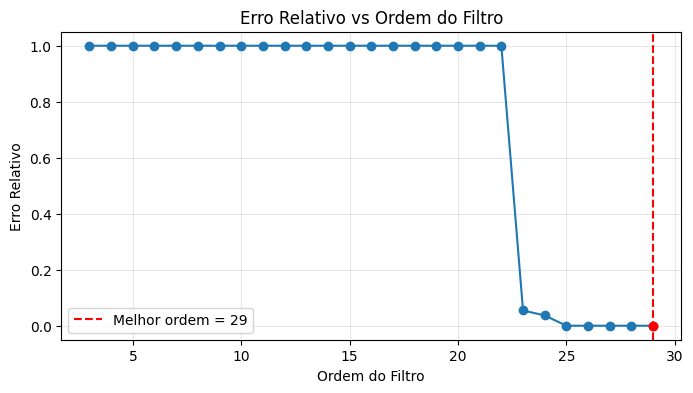

In [112]:
# se erros_por_ordem veio como dict {ordem: erro}
ordens_plot = sorted(erros_por_ordem.keys())
erros_plot = [erros_por_ordem[o] for o in ordens_plot]

print(f"Melhor ordem = {ordem_menor_erro}")
# print(f"Erro relativo (melhor ordem) = {menor_erro:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(ordens_plot, erros_plot, marker="o")
plt.axvline(
    ordem_menor_erro,
    linestyle="--",
    color="red",
    label=f"Melhor ordem = {ordem_menor_erro}",
)
plt.scatter([ordem_menor_erro], [menor_erro], color="red", zorder=3)
plt.xlabel("Ordem do Filtro")
plt.ylabel("Erro Relativo")
plt.title("Erro Relativo vs Ordem do Filtro")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [113]:
# 3) Aplicar seu WLS (função já definida no notebook)
sinal_wls = filtro_WLS(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=7,
    delay=delay_best,
    eps=1e-6,
    valor_min_clip=0,
    valor_max_clip=None,
    normalizar_pesos=True,
)

ValueError: operands could not be broadcast together with shapes (44,8) (42,1) 

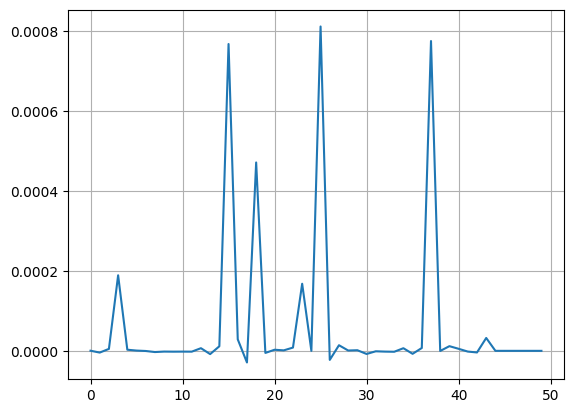

In [97]:
plt.plot(sinal_wls)
plt.grid()

In [ ]:
# 4) Plot usando Funcoes_auxiliares.py
plot_estimado_x_original(
    original=sinal_original,
    estimado=sinal_wls,
    limite_filtro=len(Readout_Shaper) - ordem_best + 1,
    title=f"Original x WLS (ordem={ordem_best}, delay={delay_fixo})",
)

In [ ]:
# 5) RMSE e MAE usando Funcoes_auxiliares.py
# (alinhando com delay e tamanho válido)
delay_fixo = 2
janela = len(Readout_Shaper) - ordem_menor_erro + 1
original_eval = np.asarray(sinal_original)[delay_fixo : delay_fixo + janela]
estimado_eval = np.asarray(sinal_wls)[:janela]

rmse, mae = RMSE_e_MAE_por_ordem(estimado_eval, original_eval, printar=True)
print(f"RMSE={rmse:.6f} | MAE={mae:.6f}")

erro_abs_medio = 3.8181
rmse = 11.4234
RMSE=11.423439 | MAE=3.818114


Media erro = -3.818109
Desvio erro = 10.766476


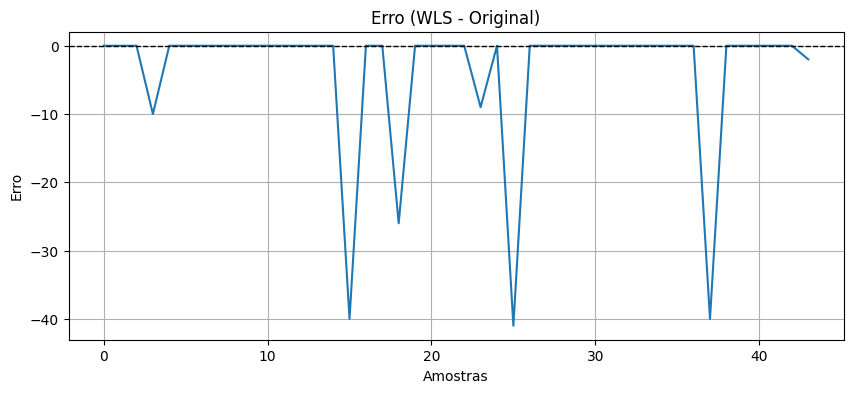

In [ ]:
# 6) Erro (resíduo) + plot do erro
erro = estimado_eval - original_eval
print(f"Media erro = {np.mean(erro):.6f}")
print(f"Desvio erro = {np.std(erro):.6f}")

plt.figure(figsize=(10, 4))
plt.plot(erro)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Erro (WLS - Original)")
plt.xlabel("Amostras")
plt.ylabel("Erro")
plt.grid(True)
plt.show()